In [1]:
#!pip install scikit-learn

In [2]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.datasets import make_circles

In [4]:
X, y = make_circles(10000,noise=0.03,random_state=42)

In [5]:
len(X), len(y)

(10000, 10000)

In [6]:
circle = pd.DataFrame({"X1" : X[:,0],
                      "X2" : X[:,1],
                      "label" : y})
circle.head(5)

,X1,X2,label
0,0.046469,0.824778,1
1,1.005063,-0.433352,0
2,-0.583484,0.794528,0
3,0.984783,-0.325179,0
4,0.829930,-0.547223,0


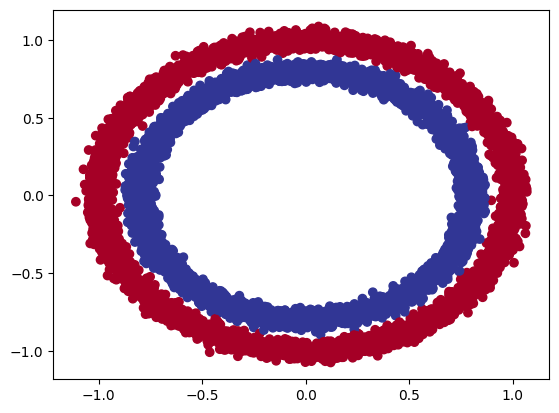

In [7]:
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [8]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [9]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
len(X_train),len(X_test),len(y_train),len(y_test)

(8000, 2000, 8000, 2000)

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [13]:
class BinaryClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=100)
        self.layer2 = nn.Linear(in_features=100, out_features=50)
        self.layer3 = nn.Linear(in_features=50, out_features=1)
    
    def forward(self, X):
        return self.layer3(self.layer2(self.layer1(X)))

In [14]:
model = BinaryClassification().to(device)

In [15]:
model

BinaryClassification(
  (layer1): Linear(in_features=2, out_features=100, bias=True)
  (layer2): Linear(in_features=100, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
)

In [16]:
# model.state_dict()

In [17]:
with torch.inference_mode():
    untrained_preds = model(X_test.to(device))

In [18]:
torch.round(untrained_preds[:10]),y_test[:10]

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]]),
 tensor([1., 1., 0., 1., 0., 1., 1., 1., 1., 1.]))

In [19]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
                         params=model.parameters(),
                         lr=0.01
)

In [20]:
torch.manual_seed(42)

In [21]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100 
    return acc

In [22]:
epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_function(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_function(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70750, Accuracy: 50.16% | Test loss: 0.70962, Test acc: 49.35%
Epoch: 10 | Loss: 0.70142, Accuracy: 50.16% | Test loss: 0.70327, Test acc: 49.35%
Epoch: 20 | Loss: 0.69793, Accuracy: 50.16% | Test loss: 0.69951, Test acc: 49.35%
Epoch: 30 | Loss: 0.69592, Accuracy: 50.16% | Test loss: 0.69725, Test acc: 49.35%
Epoch: 40 | Loss: 0.69476, Accuracy: 50.16% | Test loss: 0.69587, Test acc: 49.35%
Epoch: 50 | Loss: 0.69408, Accuracy: 50.16% | Test loss: 0.69502, Test acc: 49.35%
Epoch: 60 | Loss: 0.69369, Accuracy: 50.16% | Test loss: 0.69448, Test acc: 49.35%
Epoch: 70 | Loss: 0.69346, Accuracy: 50.16% | Test loss: 0.69413, Test acc: 49.35%
Epoch: 80 | Loss: 0.69332, Accuracy: 50.16% | Test loss: 0.69391, Test acc: 49.35%
Epoch: 90 | Loss: 0.69325, Accuracy: 50.16% | Test loss: 0.69375, Test acc: 49.35%
Epoch: 100 | Loss: 0.69320, Accuracy: 50.16% | Test loss: 0.69365, Test acc: 49.35%
Epoch: 110 | Loss: 0.69317, Accuracy: 57.15% | Test loss: 0.69357, Test acc: 56.75%
Epo

In [23]:
class SuperBinaryClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=256)
        self.layer2 = nn.Linear(in_features=256, out_features=128)
        self.layer3 = nn.Linear(in_features=128, out_features=10)
        self.layer4 = nn.Linear(in_features=10, out_features=5)
        self.layer5 = nn.Linear(in_features=5, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.layer5(self.relu(self.layer4(self.relu(self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))))))

In [24]:
superModel = SuperBinaryClassification().to(device)

In [25]:
superModel

SuperBinaryClassification(
  (layer1): Linear(in_features=2, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=10, bias=True)
  (layer4): Linear(in_features=10, out_features=5, bias=True)
  (layer5): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)

In [26]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(superModel.parameters(), lr = 0.01)

In [27]:
epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    superModel.train()
    
    y_logits = superModel(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) 
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    superModel.eval()
    with torch.inference_mode():
        test_logits = superModel(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_function(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69394, Accuracy: 50.16% | Test loss: 0.68881, Test acc: 50.65%
Epoch: 100 | Loss: 0.02018, Accuracy: 100.00% | Test loss: 0.02020, Test acc: 99.95%
Epoch: 200 | Loss: 0.00009, Accuracy: 100.00% | Test loss: 0.00104, Test acc: 99.95%
Epoch: 300 | Loss: 0.00003, Accuracy: 100.00% | Test loss: 0.00108, Test acc: 99.95%
Epoch: 400 | Loss: 0.00002, Accuracy: 100.00% | Test loss: 0.00115, Test acc: 99.95%
Epoch: 500 | Loss: 0.00001, Accuracy: 100.00% | Test loss: 0.00120, Test acc: 99.95%
Epoch: 600 | Loss: 0.00001, Accuracy: 100.00% | Test loss: 0.00124, Test acc: 99.95%
Epoch: 700 | Loss: 0.00001, Accuracy: 100.00% | Test loss: 0.00127, Test acc: 99.95%
Epoch: 800 | Loss: 0.00000, Accuracy: 100.00% | Test loss: 0.00130, Test acc: 99.95%
Epoch: 900 | Loss: 0.00000, Accuracy: 100.00% | Test loss: 0.00133, Test acc: 99.95%
